# Setup

In [3]:
from pathlib import Path
import pandas as pd

import keypoint_moseq as kpms

WORKDIR = Path.cwd().parent
dlc_project_dir = WORKDIR.parent / "dlc-pose-estimation" / "ElevatedMazeFood-Atanu-2026-04-04"
project_dir = WORKDIR / "results" / "ElevatedMazeFood"
config = kpms.load_config(str(project_dir))
model_name = project_dir / "multi_fit_20260708-13"

# load data (e.g. from DeepLabCut)
keypoint_data_path = str(dlc_project_dir / "raw_pose_data")  # can be a file, a directory, or a list of files
coordinates, confidences, bodyparts = kpms.load_keypoints(keypoint_data_path, "deeplabcut")

Loading keypoints: 100%|████████████████| 23/23 [00:00<00:00, 87.66it/s]


In [8]:
FPS = 15.0
MIN_FREQUENCY = 0.005

# Assign Groups

In [5]:
import inspect, keypoint_moseq as kpms
print(inspect.getsource(kpms.interactive_group_setting))

def interactive_group_setting(project_dir, model_name):
    """Start the interactive group setting widget.

    Parameters
    ----------
    project_dir : str
        the path to the project directory
    model_name : str
        the name of the model directory
    """

    index_filepath = os.path.join(project_dir, "index.csv")

    if not os.path.exists(index_filepath):
        generate_index(project_dir, model_name, index_filepath)

    # making the interactive dataframe
    # open index dataframe

    # make a tabulator dataframe
    summary_data = pd.read_csv(index_filepath, index_col=False)

    titles = {"name": "recording name", "group": "group"}

    editors = {
        "name": None,
        "group": {
            "type": "textarea",
            "elementAttributes": {
                "maxlength": "100",
                "onkeydown": "if(event.keyCode == 13 && !event.shiftKey){this.blur();}",
            },
            "selectContents": True,
            "verticalNavigation": "

In [4]:
kpms.interactive_group_setting(str(project_dir), str(model_name))

BokehModel(combine_events=True, render_bundle={'docs_json': {'71436359-02ca-428a-a8ad-6bde3f041a85': {'defs': …

# Generate dataframes

In [6]:
moseq_df = kpms.compute_moseq_df(project_dir, model_name, smooth_heading=True)
moseq_df

,name,centroid_x,centroid_y,heading,angular_velocity,velocity_px_s,syllable,frame_index,group,onset
0,ElevatedMazeFood_08_26_24_P_AzulDLC_Resnet101_...,210.176695,306.389913,1.433492,0.000000,0.000000,14,0,gh,True
1,ElevatedMazeFood_08_26_24_P_AzulDLC_Resnet101_...,211.271490,307.969371,1.400159,-0.017547,57.653597,14,1,gh,False
2,ElevatedMazeFood_08_26_24_P_AzulDLC_Resnet101_...,210.936997,307.309888,1.433492,-0.037397,22.183845,14,2,gh,False
3,ElevatedMazeFood_08_26_24_P_AzulDLC_Resnet101_...,210.736760,307.136822,1.433492,-0.058934,7.939890,14,3,gh,False
4,ElevatedMazeFood_08_26_24_P_AzulDLC_Resnet101_...,210.284531,306.124870,1.433492,-0.077860,33.252115,9,4,gh,True
...,...,...,...,...,...,...,...,...,...,...
225302,ElevatedMazeFood_09_03_24_Y_SkyDLC_Resnet101_E...,66.419607,214.940012,0.434136,0.027126,11.293618,29,9823,default,False
225303,ElevatedMazeFood_09_03_24_Y_SkyDLC_Resnet101_E...,67.223378,214.850353,0.434136,0.029994,24.262661,29,9824,default,False
225304,ElevatedMazeFood_09_03_24_Y_SkyDLC_Resnet101_E...,65.950442,214.834743,0.436852,0.027604,38.190946,29,9825,default,False
225305,ElevatedMazeFood_09_03_24_Y_SkyDLC_Resnet101_E...,65.338245,215.680645,0.436852,0.020717,31.325735,29,9826,default,False


In [9]:
stats_df = kpms.compute_stats_df(
    project_dir,
    model_name,
    moseq_df,
    min_frequency=MIN_FREQUENCY,  # threshold frequency for including a syllable in the dataframe
    groupby=["group", "name"],  # column(s) to group the dataframe by
    fps=FPS,
)  # frame rate of the video from which keypoints were inferred

stats_df

,group,name,syllable,heading_mean,heading_std,heading_min,heading_max,angular_velocity_mean,angular_velocity_std,angular_velocity_min,angular_velocity_max,velocity_px_s_mean,velocity_px_s_std,velocity_px_s_min,velocity_px_s_max,frequency,duration
0,default,ElevatedMazeFood_08_26_24_Y_CyanDLC_Resnet101_...,0,-0.233540,2.053889,-3.136993,3.135883,0.166274,20.447598,-187.860129,187.657085,73.363363,53.748174,5.825410,272.112523,0.111562,0.410909
1,default,ElevatedMazeFood_08_26_24_Y_CyanDLC_Resnet101_...,1,-0.993391,1.913324,-3.140897,3.137672,0.374259,17.737182,-188.237337,187.819739,56.783170,41.460416,0.585848,220.879555,0.089249,0.519697
2,default,ElevatedMazeFood_08_26_24_Y_CyanDLC_Resnet101_...,2,-0.482857,1.669077,-3.135313,3.135933,-0.187875,21.428563,-188.315113,187.794934,44.794661,32.087607,1.429168,255.119729,0.079108,0.923077
3,default,ElevatedMazeFood_08_26_24_Y_CyanDLC_Resnet101_...,3,0.614669,1.690582,-3.123762,3.125396,-2.021957,14.359127,-187.376526,8.554631,47.684733,34.038505,2.152423,227.664700,0.046653,0.504348
4,default,ElevatedMazeFood_08_26_24_Y_CyanDLC_Resnet101_...,4,0.403352,2.373242,-3.074862,3.135686,-0.078045,19.038999,-17.190993,184.839801,75.739246,47.244122,10.880218,215.649462,0.042596,0.339683
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
687,gh,ElevatedMazeFood_09_03_24_P_VioletDLC_Resnet10...,26,-0.197719,0.805954,-1.633441,1.676730,0.200615,1.007894,-4.394384,2.909090,36.285162,20.405238,2.067520,112.366359,0.010776,2.626667
688,gh,ElevatedMazeFood_09_03_24_P_VioletDLC_Resnet10...,27,0.953921,1.594839,-3.135597,2.975738,0.389701,25.803666,-187.638934,187.008865,39.744573,22.977149,1.978497,110.763542,0.017241,0.891667
689,gh,ElevatedMazeFood_09_03_24_P_VioletDLC_Resnet10...,28,-1.371129,0.709534,-2.323576,1.895946,-0.008772,0.382179,-2.346488,1.425896,32.732576,17.705693,1.064742,147.115790,0.010776,15.706667
690,gh,ElevatedMazeFood_09_03_24_P_VioletDLC_Resnet10...,29,0.866385,2.071578,-2.986861,2.622492,-2.758911,22.635290,-182.956211,5.913076,67.471989,34.326106,6.519373,133.860422,0.019397,0.488889


# Label syllables

In [10]:
kpms.label_syllables(str(project_dir), str(model_name), moseq_df)

BokehModel(combine_events=True, render_bundle={'docs_json': {'332d91bf-6bfa-45e8-b6d8-28320586a707': {'defs': …

# Compare between groups

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

No significant syllables found.
Saved figure to /Users/atanugiri/Downloads/kpms_analysis_2/results/ElevatedMazeFood/multi_fit_20260708-13/figures/frequency_stat_stats.png


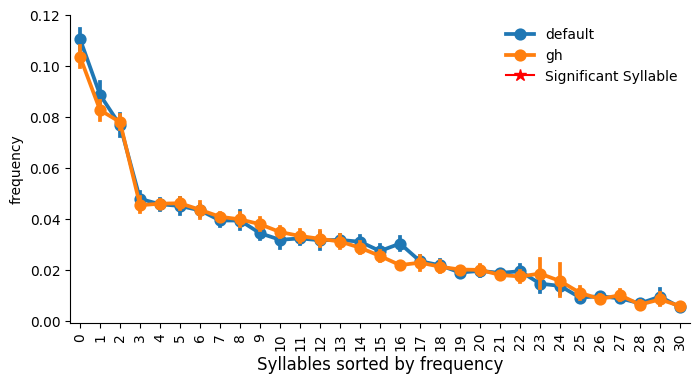

In [11]:
kpms.plot_syll_stats_with_sem(
    stats_df,
    project_dir,
    model_name,
    plot_sig=True,  # whether to mark statistical significance with a star
    thresh=0.05,  # significance threshold
    stat="frequency",  # statistic to be plotted (e.g. 'duration' or 'velocity_px_s_mean')
    order="stat",  # order syllables by overall frequency ("stat") or degree of difference ("diff")
    ctrl_group="a",  # name of the control group for statistical testing
    exp_group="b",  # name of the experimental group for statistical testing
    figsize=(8, 4),  # figure size
    groups=stats_df["group"].unique(),  # groups to be plotted
);

## Transition matrices

In [ ]:
normalize = "bigram"  # normalization method ("bigram", "rows" or "columns")

trans_mats, usages, groups, syll_include = kpms.generate_transition_matrices(
    project_dir,
    model_name,
    normalize=normalize,
    min_frequency=MIN_FREQUENCY,  # minimum syllable frequency to include
)

kpms.visualize_transition_bigram(
    project_dir,
    model_name,
    groups,
    trans_mats,
    syll_include,
    normalize=normalize,
    show_syllable_names=True,  # label syllables by index (False) or index and name (True)
)

## Syllable Transition Graph

In [ ]:
kpms.plot_transition_graph_group(
    project_dir,
    model_name,
    groups,
    trans_mats,
    usages,
    syll_include,
    layout="circular",  # transition graph layout ("circular" or "spring")
    show_syllable_names=False,  # label syllables by index (False) or index and name (True)
)

In [ ]:
# Generate a difference-graph for each pair of groups.

kpms.plot_transition_graph_difference(
    project_dir, model_name, groups, trans_mats, usages, syll_include, layout="circular"
) 